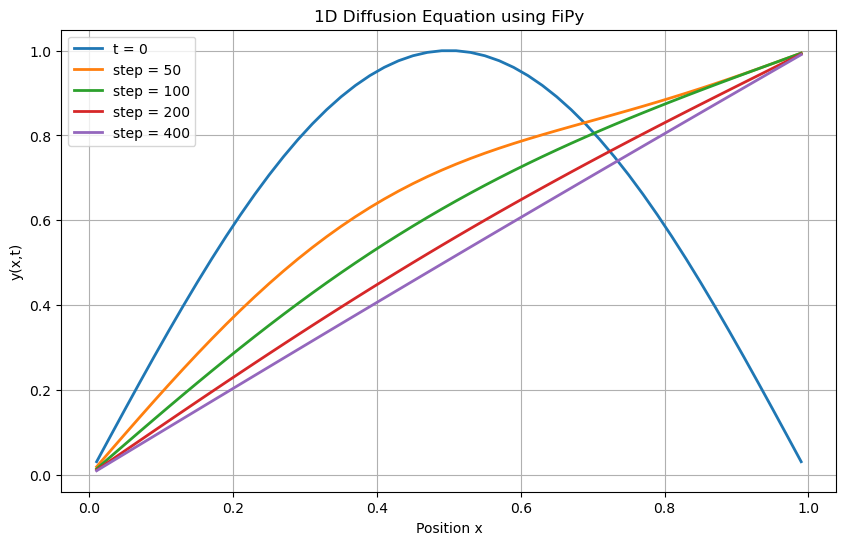

In [3]:
# =====================================================
# CASE 1 : DIRICHLET BOUNDARY CONDITION WITHOUT SOURCE
# TRANSIENT STUDY
# =====================================================

# Governing Equation:
#
#     ∂y/∂t = k ∂²y/∂x²
#
# Boundary Conditions:
#
#     y(0) = 0
#     y(1) = 1
#
# Initial Condition (Assumed for Transient Analysis):
#
#     y(x,0) = sin(πx)
#
# Note:
# Initial condition is introduced for transient
# numerical analysis because it is not specified
# in the original board problem.
#
# =====================================================
# NUMERICAL PARAMETERS
# =====================================================
#
# nx : Number of Spatial Cells
#
#      The domain is divided into nx cells.
#
#      Value = 50
#
# dx : Spatial Step Size
#
#      Size of each computational cell.
#
#      dx = L / nx = 0.02
#
# dt : Time Step Size
#
#      Amount of time advanced in one iteration.
#
#      Value = 1e-3
#
# steps : Number of Time Steps
#
#         Total number of iterations.
#
#         Value = 2000
#
# t_final : Final Simulation Time
#
#           t_final = dt × steps
#
#                   = 2.0

from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
nx = 50
dx = L / nx

k = 1.0

dt = 1e-3
steps = 2000

# =====================================================
# MESH
# =====================================================

mesh = Grid1D(nx=nx, dx=dx)

x = mesh.cellCenters[0]

# =====================================================
# INITIAL CONDITION
# =====================================================

y = CellVariable(
    name="y",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

y_initial = np.array(y.value)

# =====================================================
# DIRICHLET BOUNDARY CONDITIONS
# =====================================================

y.constrain(0.0, mesh.facesLeft)
y.constrain(1.0, mesh.facesRight)

# =====================================================
# GOVERNING EQUATION
# =====================================================

eq = TransientTerm() == DiffusionTerm(coeff=k)

# =====================================================
# TRANSIENT EVOLUTION
# =====================================================

plt.figure(figsize=(10,6))

plt.plot(
    x,
    y_initial,
    linewidth=2,
    label='t = 0'
)

plot_steps = [50, 100, 200, 400]

for step in range(1, steps + 1):

    eq.solve(var=y, dt=dt)

    if step in plot_steps:

        plt.plot(
            x,
            np.array(y.value),
            linewidth=2,
            label=f'step = {step}'
        )

plt.title("1D Diffusion Equation using FiPy")
plt.xlabel("Position x")
plt.ylabel("y(x,t)")

plt.legend()
plt.grid(True)
plt.savefig("transient_evolution.png", dpi=300, bbox_inches='tight')
plt.show()


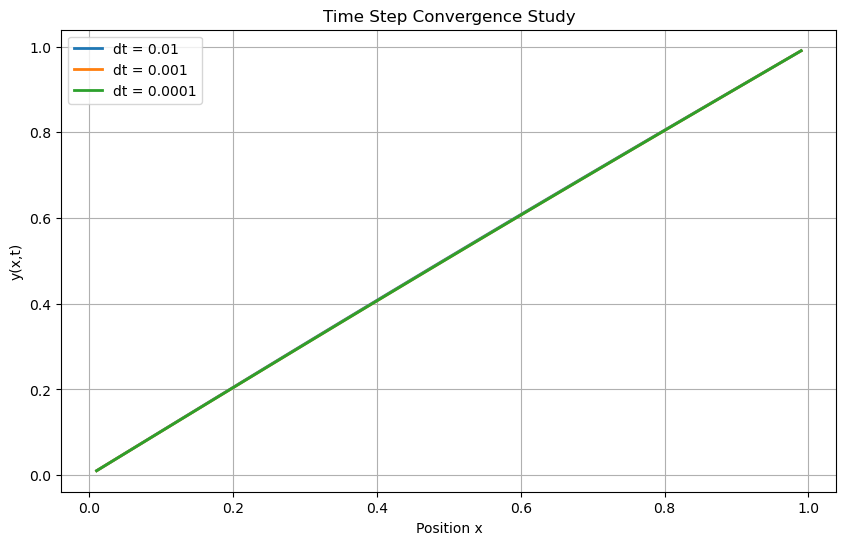

In [4]:
# =====================================================
# CASE 1 : DIRICHLET BOUNDARY CONDITION WITHOUT SOURCE
# TIME STEP CONVERGENCE STUDY
# =====================================================

# Governing Equation:
#
#     ∂y/∂t = k ∂²y/∂x²
#
# Boundary Conditions:
#
#     y(0) = 0
#     y(1) = 1
#
# Initial Condition (Assumed):
#
#     y(x,0) = sin(πx)
#
# Purpose:
#
#     Study the effect of time step size
#     on the numerical solution.
#
# Fixed Parameters:
#
#     k  = 1.0
#     L  = 1.0
#     nx = 50
#
# Time Steps Compared:
#
#     dt = 1e-2
#     dt = 1e-3
#     dt = 1e-4

from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
nx = 50
dx = L / nx

k = 1.0

dt_values = [1e-2, 1e-3, 1e-4]

final_time = 0.4

plt.figure(figsize=(10,6))

# =====================================================
# LOOP OVER DIFFERENT dt VALUES
# =====================================================

for dt in dt_values:

    mesh = Grid1D(nx=nx, dx=dx)

    x = np.array(mesh.cellCenters[0])

    y = CellVariable(
        name="y",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    y.constrain(0.0, mesh.facesLeft)
    y.constrain(1.0, mesh.facesRight)

    eq = TransientTerm() == DiffusionTerm(coeff=k)

    steps = int(final_time / dt)

    for step in range(steps):

        eq.solve(var=y, dt=dt)

    plt.plot(
        x,
        np.array(y.value),
        linewidth=2,
        label=f'dt = {dt}'
    )

# =====================================================
# PLOT
# =====================================================

plt.title("Time Step Convergence Study")
plt.xlabel("Position x")
plt.ylabel("y(x,t)")

plt.legend()
plt.grid(True)
plt.savefig("Timestep_convergence.png", dpi=300, bbox_inches='tight')
plt.show()


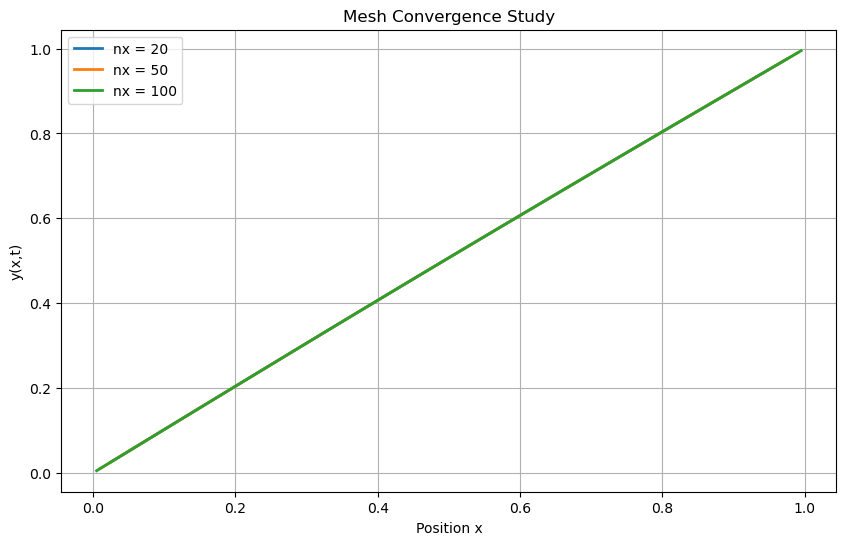

In [7]:
# =====================================================
# CASE 1 : DIRICHLET BOUNDARY CONDITION WITHOUT SOURCE
# MESH CONVERGENCE STUDY
# =====================================================

# Governing Equation:
#
#     ∂y/∂t = k ∂²y/∂x²
#
# Boundary Conditions:
#
#     y(0) = 0
#     y(1) = 1
#
# Initial Condition (Assumed):
#
#     y(x,0) = sin(πx)
#
# Purpose:
#
#     Study the effect of spatial mesh
#     refinement on the numerical solution.
#
# Fixed Parameters:
#
#     k  = 1.0
#     dt = 1e-3
#
# Meshes Compared:
#
#     nx = 20
#     nx = 50
#     nx = 100

from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
k = 1.0

dt = 1e-3
final_time = 0.4

nx_values = [20, 50, 100]

plt.figure(figsize=(10,6))

# =====================================================
# LOOP OVER DIFFERENT MESHES
# =====================================================

for nx in nx_values:

    dx = L / nx

    mesh = Grid1D(nx=nx, dx=dx)

    x = np.array(mesh.cellCenters[0])

    y = CellVariable(
        name="y",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    y.constrain(0.0, mesh.facesLeft)
    y.constrain(1.0, mesh.facesRight)

    eq = TransientTerm() == DiffusionTerm(coeff=k)

    steps = int(final_time / dt)

    for step in range(steps):

        eq.solve(var=y, dt=dt)

    plt.plot(
        x,
        np.array(y.value),
        linewidth=2,
        label=f'nx = {nx}'
    )

# =====================================================
# PLOT
# =====================================================

plt.title("Mesh Convergence Study")
plt.xlabel("Position x")
plt.ylabel("y(x,t)")

plt.legend()
plt.grid(True)
plt.savefig("Mesh_convergence.png", dpi=300, bbox_inches='tight')
plt.show()


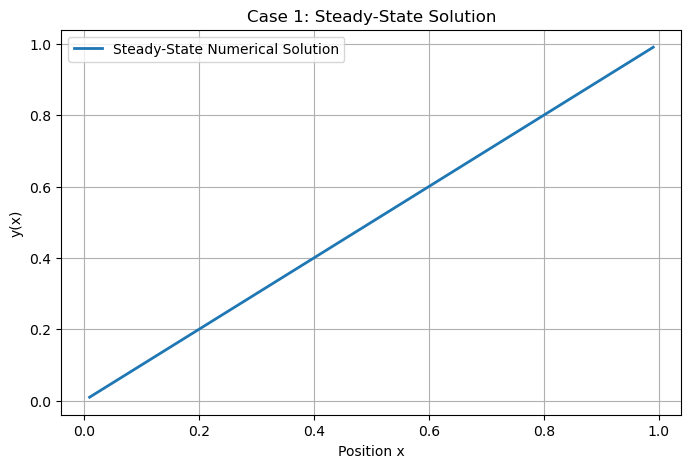

In [8]:
# =====================================================
# CASE 1 : DIRICHLET BOUNDARY CONDITION WITHOUT SOURCE
# STEADY-STATE STUDY
# =====================================================

# Governing Equation:
#
#     ∂y/∂t = k ∂²y/∂x²
#
# Boundary Conditions:
#
#     y(0) = 0
#     y(1) = 1
#
# Initial Condition (Assumed):
#
#     y(x,0) = sin(πx)
#
# Purpose:
#
#     Observe convergence of the transient
#     solution toward steady state.
#
# Parameters:
#
#     k     = 1.0   (Diffusion Coefficient)
#     L     = 1.0   (Domain Length)
#     nx    = 50    (Number of Spatial Cells)
#     dx    = 0.02  (Spatial Step Size)
#     dt    = 1e-3  (Time Step Size)
#     steps = 5000  (Number of Time Steps)

from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
nx = 50
dx = L / nx

k = 1.0

dt = 1e-3
steps = 5000

# =====================================================
# MESH
# =====================================================

mesh = Grid1D(nx=nx, dx=dx)

x = np.array(mesh.cellCenters[0])

# =====================================================
# INITIAL CONDITION
# =====================================================

y = CellVariable(
    name="y",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

# =====================================================
# BOUNDARY CONDITIONS
# =====================================================

y.constrain(0.0, mesh.facesLeft)
y.constrain(1.0, mesh.facesRight)

# =====================================================
# GOVERNING EQUATION
# =====================================================

eq = TransientTerm() == DiffusionTerm(coeff=k)

# =====================================================
# TRANSIENT TO STEADY STATE
# =====================================================

for step in range(steps):

    eq.solve(var=y, dt=dt)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    np.array(y.value),
    linewidth=2,
    label='Steady-State Numerical Solution'
)

plt.title("Case 1: Steady-State Solution")
plt.xlabel("Position x")
plt.ylabel("y(x)")

plt.grid(True)
plt.legend()
plt.savefig("steady_state_solution.png", dpi=300, bbox_inches='tight')
plt.show()


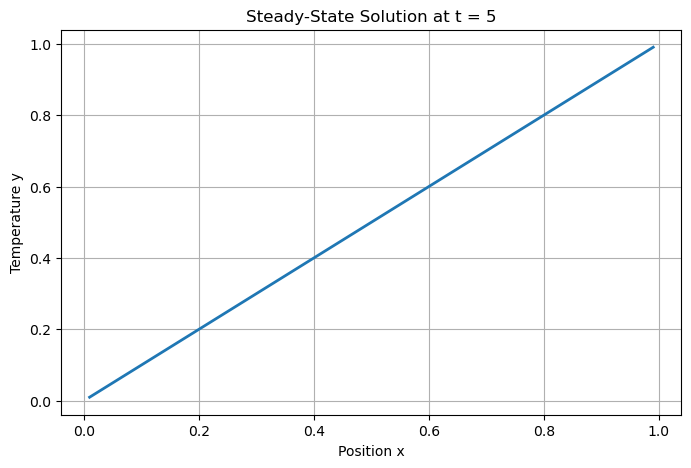

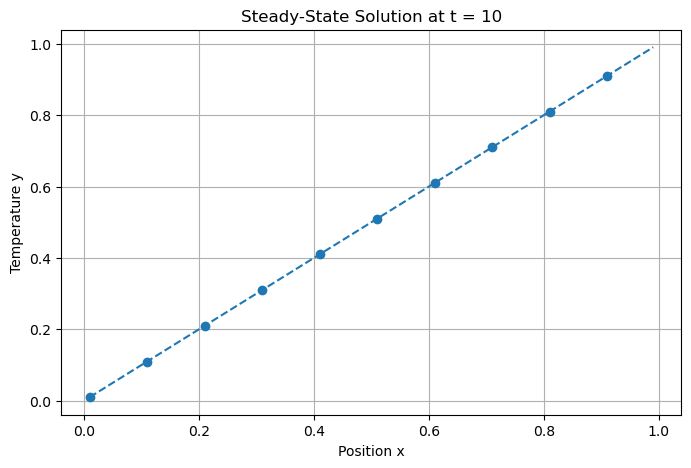

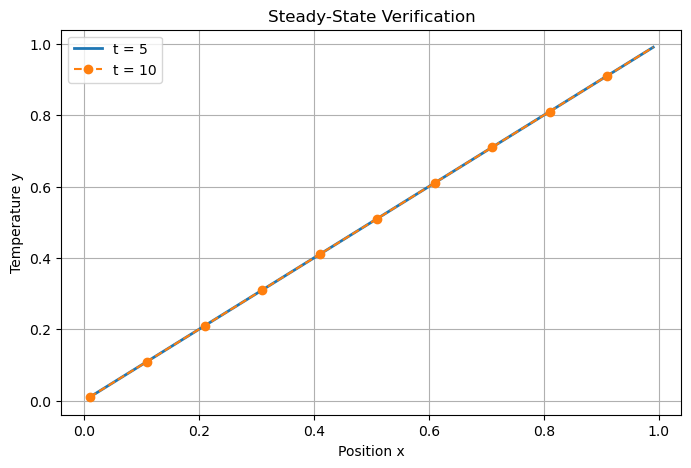

In [ ]:
# =====================================================
# CASE 1 : STEADY-STATE VERIFICATION
# =====================================================

from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
nx = 50
dx = L / nx

k = 1.0
dt = 1e-3

# =====================================================
# MESH
# =====================================================

mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# =====================================================
# SOLUTION AT t = 5
# =====================================================

y_t5 = CellVariable(
    name="y",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

y_t5.constrain(0.0, mesh.facesLeft)
y_t5.constrain(1.0, mesh.facesRight)

eq = TransientTerm() == DiffusionTerm(coeff=k)

for step in range(5000):
    eq.solve(var=y_t5, dt=dt)

solution_t5 = np.array(y_t5.value)

# =====================================================
# SOLUTION AT t = 10
# =====================================================

y_t10 = CellVariable(
    name="y",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

y_t10.constrain(0.0, mesh.facesLeft)
y_t10.constrain(1.0, mesh.facesRight)

for step in range(10000):
    eq.solve(var=y_t10, dt=dt)

solution_t10 = np.array(y_t10.value)

# =====================================================
# PLOT 1 : t = 5
# =====================================================

plt.figure(figsize=(8,5))
plt.plot(x, solution_t5, linewidth=2)
plt.title("Steady-State Solution at t = 5")
plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.grid(True)
plt.savefig("steady_state_t5.png", dpi=300)
plt.show()

# =====================================================
# PLOT 2 : t = 10
# =====================================================

plt.figure(figsize=(8,5))
plt.plot(x, solution_t10, 'o--', markevery=5)
plt.title("Steady-State Solution at t = 10")
plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.grid(True)
plt.savefig("steady_state_t10.png", dpi=300)
plt.show()

# =====================================================
# PLOT 3 : COMPARISON
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    solution_t5,
    linewidth=2,
    label='t = 5'
)

plt.plot(
    x,
    solution_t10,
    'o--',
    markevery=5,
    label='t = 10'
)

plt.title("Steady-State Verification")
plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.legend()
plt.grid(True)

plt.savefig("steady_state_comparison.png", dpi=300)
plt.savefig("steady_state_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


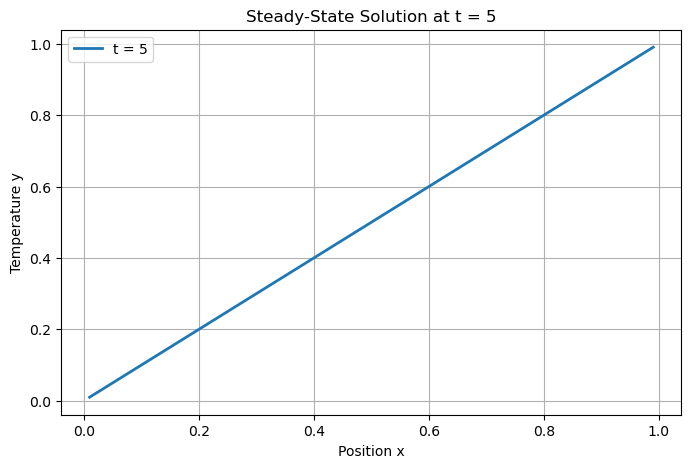

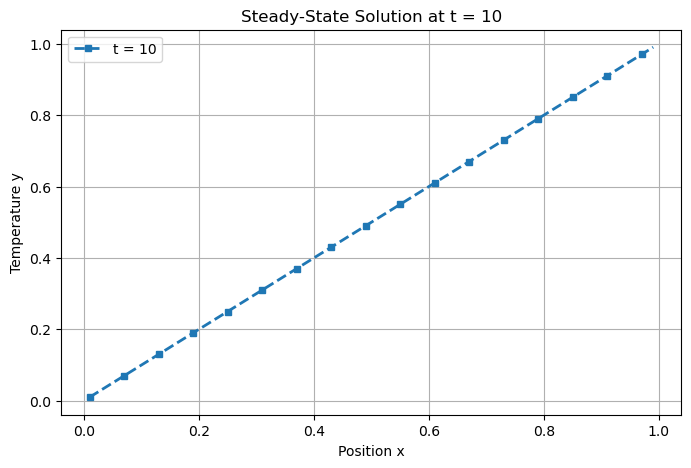

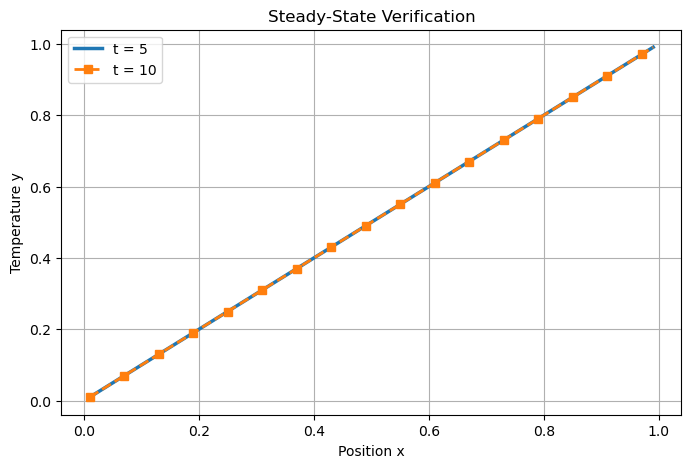


========== STEADY-STATE VERIFICATION ==========
Maximum Difference between t=5 and t=10 = 4.440892e-16


In [9]:
# =====================================================
# CASE 1 : STEADY-STATE VERIFICATION
# =====================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
nx = 50
dx = L / nx

dt = 1e-3

# =====================================================
# MESH
# =====================================================

mesh = Grid1D(nx=nx, dx=dx)
x = np.array(mesh.cellCenters[0])

# =====================================================
# SOLUTION AT t = 5
# =====================================================

phi_t5 = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

phi_t5.constrain(0.0, mesh.facesLeft)
phi_t5.constrain(1.0, mesh.facesRight)

eq = TransientTerm() == DiffusionTerm(coeff=1.0)

for step in range(5000):      # t = 5
    eq.solve(var=phi_t5, dt=dt)

solution_t5 = np.array(phi_t5.value)

# =====================================================
# SOLUTION AT t = 10
# =====================================================

phi_t10 = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

phi_t10.constrain(0.0, mesh.facesLeft)
phi_t10.constrain(1.0, mesh.facesRight)

eq = TransientTerm() == DiffusionTerm(coeff=1.0)

for step in range(10000):     # t = 10
    eq.solve(var=phi_t10, dt=dt)

solution_t10 = np.array(phi_t10.value)

# =====================================================
# PLOT 1 : t = 5
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    solution_t5,
    linewidth=2,
    label='t = 5'
)

plt.title("Steady-State Solution at t = 5")
plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.grid(True)
plt.legend()

plt.savefig("steady_state_t5.png", dpi=300, bbox_inches='tight')

plt.show()

# =====================================================
# PLOT 2 : t = 10
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    solution_t10,
    's--',
    markersize=5,
    markevery=3,
    linewidth=2,
    label='t = 10'
)

plt.title("Steady-State Solution at t = 10")
plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.grid(True)
plt.legend()

plt.savefig("steady_state_t10.png", dpi=300, bbox_inches='tight')

plt.show()

# =====================================================
# PLOT 3 : COMPARISON
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    solution_t5,
    linewidth=2.5,
    label='t = 5'
)

plt.plot(
    x,
    solution_t10,
    's--',
    markersize=6,
    markevery=3,
    linewidth=2,
    label='t = 10'
)

plt.title("Steady-State Verification")
plt.xlabel("Position x")
plt.ylabel("Temperature y")
plt.legend()
plt.grid(True)

plt.savefig(
    "steady_state_verification.png",
    dpi=300,
    bbox_inches='tight'
)


plt.show()

# =====================================================
# MAX DIFFERENCE BETWEEN THE TWO SOLUTIONS
# =====================================================

difference = np.max(np.abs(solution_t10 - solution_t5))

print("\n========== STEADY-STATE VERIFICATION ==========")
print(f"Maximum Difference between t=5 and t=10 = {difference:.6e}")

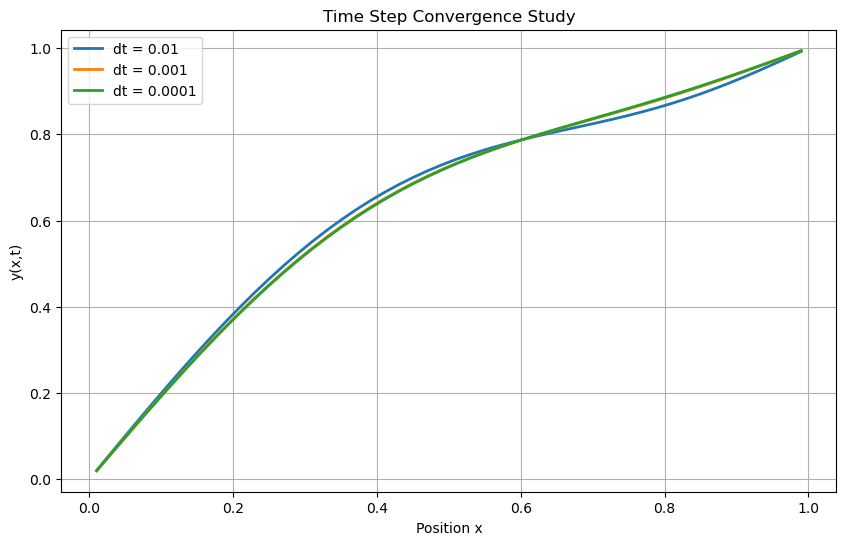

In [17]:
# =====================================================
# CASE 1 : DIRICHLET BOUNDARY CONDITION WITHOUT SOURCE
# TIME STEP CONVERGENCE STUDY
# =====================================================

from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
nx = 50
dx = L / nx

k = 1.0

dt_values = [1e-2, 1e-3, 1e-4]

# Reduced final time to capture transient differences
final_time = 0.05

plt.figure(figsize=(10,6))

for dt in dt_values:

    mesh = Grid1D(nx=nx, dx=dx)

    x = np.array(mesh.cellCenters[0])

    y = CellVariable(
        name="y",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    y.constrain(0.0, mesh.facesLeft)
    y.constrain(1.0, mesh.facesRight)

    eq = TransientTerm() == DiffusionTerm(coeff=k)

    steps = int(final_time / dt)

    for step in range(steps):
        eq.solve(var=y, dt=dt)

    plt.plot(
        x,
        np.array(y.value),
        linewidth=2,
        label=f'dt = {dt}'
    )

plt.title("Time Step Convergence Study")
plt.xlabel("Position x")
plt.ylabel("y(x,t)")

plt.legend()
plt.grid(True)

plt.show()

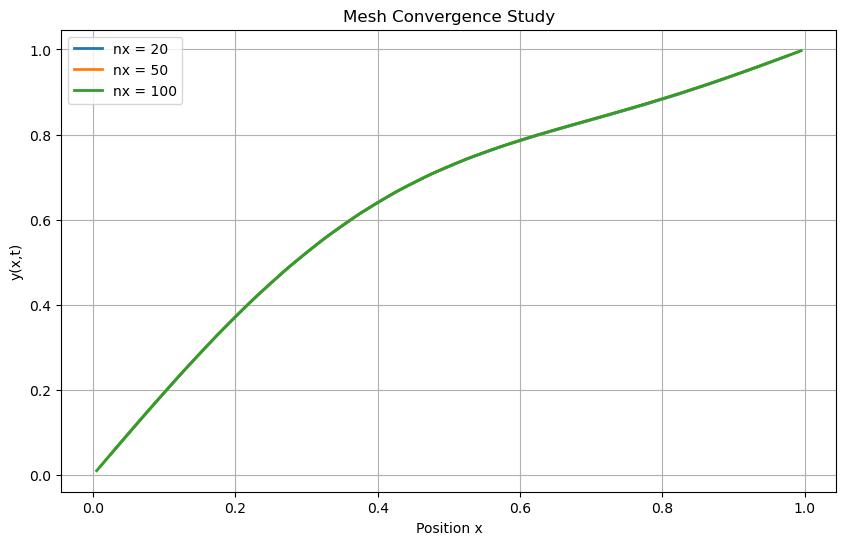

In [18]:
# =====================================================
# CASE 1 : DIRICHLET BOUNDARY CONDITION WITHOUT SOURCE
# MESH CONVERGENCE STUDY
# =====================================================

from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
k = 1.0

dt = 1e-3

# Reduced final time to capture transient differences
final_time = 0.05

nx_values = [20, 50, 100]

plt.figure(figsize=(10,6))

for nx in nx_values:

    dx = L / nx

    mesh = Grid1D(nx=nx, dx=dx)

    x = np.array(mesh.cellCenters[0])

    y = CellVariable(
        name="y",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    y.constrain(0.0, mesh.facesLeft)
    y.constrain(1.0, mesh.facesRight)

    eq = TransientTerm() == DiffusionTerm(coeff=k)

    steps = int(final_time / dt)

    for step in range(steps):
        eq.solve(var=y, dt=dt)

    plt.plot(
        x,
        np.array(y.value),
        linewidth=2,
        label=f'nx = {nx}'
    )

plt.title("Mesh Convergence Study")
plt.xlabel("Position x")
plt.ylabel("y(x,t)")

plt.legend()
plt.grid(True)

plt.show()

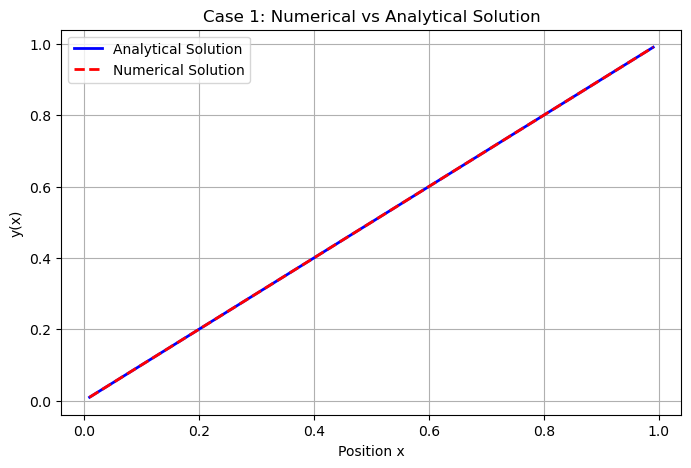

In [5]:
# =====================================================
# CASE 1 : NUMERICAL vs ANALYTICAL COMPARISON
# =====================================================

# Analytical Solution:
#
#     y(x) = x
#
# Purpose:
#
#     Compare the steady-state numerical solution
#     obtained using FiPy with the exact analytical
#     solution.

from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS
# =====================================================

L = 1.0
nx = 50
dx = L / nx

k = 1.0

dt = 1e-3
steps = 5000

# =====================================================
# MESH
# =====================================================

mesh = Grid1D(nx=nx, dx=dx)

x = np.array(mesh.cellCenters[0])

# =====================================================
# NUMERICAL SOLUTION
# =====================================================

y = CellVariable(
    name="y",
    mesh=mesh,
    value=np.sin(np.pi * x)
)

# Boundary Conditions
y.constrain(0.0, mesh.facesLeft)
y.constrain(1.0, mesh.facesRight)

# Governing Equation
eq = TransientTerm() == DiffusionTerm(coeff=k)

# Time Marching
for step in range(steps):
    eq.solve(var=y, dt=dt)

numerical = np.array(y.value)

# =====================================================
# ANALYTICAL SOLUTION
# =====================================================

analytical = x

# =====================================================
# COMPARISON PLOT
# =====================================================

plt.figure(figsize=(8,5))

# Analytical Solution (continuous line)
plt.plot(
    x,
    analytical,
    'b-',
    linewidth=2,
    label='Analytical Solution'
)

# Numerical Solution (dashed line with square markers)
plt.plot(
    x,
    numerical,
    'r--',
    linewidth=2,
    label='Numerical Solution'
)

plt.title("Case 1: Numerical vs Analytical Solution")
plt.xlabel("Position x")
plt.ylabel("y(x)")

plt.legend()
plt.grid(True)

plt.savefig(
    "numerical_analytical_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


========== ERROR ANALYSIS ==========
Maximum Error = 4.529710e-14
L2 Error      = 3.245800e-14


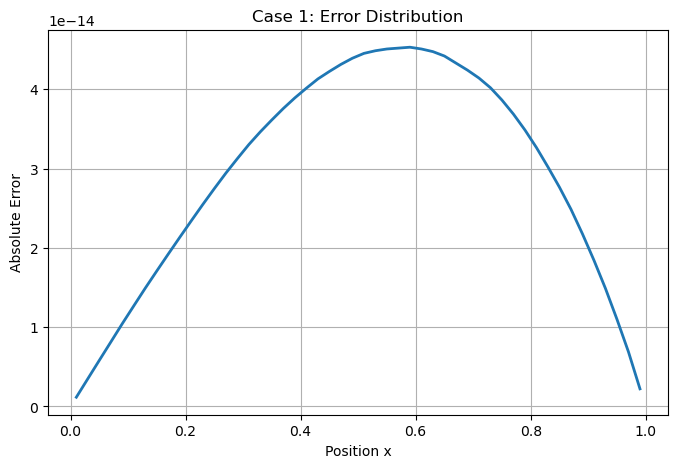

In [14]:
# =====================================================
# CASE 1 : ERROR ANALYSIS
# =====================================================

# Purpose:
#
#     Quantify the difference between the
#     numerical and analytical solutions.
#
# Metrics:
#
#     1. Maximum Error
#     2. L2 Error Norm

import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# ERROR CALCULATION
# =====================================================

error = np.abs(numerical - analytical)

max_error = np.max(error)

l2_error = np.sqrt(np.mean(error**2))

# =====================================================
# PRINT RESULTS
# =====================================================

print("\n========== ERROR ANALYSIS ==========")

print(f"Maximum Error = {max_error:.6e}")

print(f"L2 Error      = {l2_error:.6e}")

# =====================================================
# ERROR DISTRIBUTION PLOT
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    x,
    error,
    linewidth=2
)

plt.title("Case 1: Error Distribution")

plt.xlabel("Position x")
plt.ylabel("Absolute Error")

plt.grid(True)
plt.savefig("error_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


Those error values are extremely small:

Maximum Error = 4.53×10
−14
L2 Error = 3.25×10
−14